# Recurrent Neural Network Implementation from Scratch
:label:`sec_rnn-scratch`

We are now ready to implement an RNN from scratch.
In particular, we will train this RNN to function
as a character-level language model
(see :numref:`sec_rnn`)
and train it on a corpus consisting of 
the entire text of H. G. Wells' *The Time Machine*,
following the data processing steps 
outlined in :numref:`sec_text-sequence`.
We start by loading the dataset.



# 从零实现循环神经网络
:label:`sec_rnn-scratch`

现在我们将从零开始实现一个循环神经网络。该RNN将作为字符级语言模型（参见 :numref:`sec_rnn`）在H.G.威尔斯的《时间机器》全文语料库上进行训练，数据预处理流程遵循 :numref:`sec_text-sequence` 的规范。我们首先加载数据集。


In [1]:
%matplotlib inline
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

## RNN Model

We begin by defining a class 
to implement the RNN model
(:numref:`subsec_rnn_w_hidden_states`).
Note that the number of hidden units `num_hiddens` 
is a tunable hyperparameter.


## RNN 模型


我们首先定义一个类来实现RNN模型（参见 :numref:`subsec_rnn_w_hidden_states`）。注意隐藏单元数`num_hiddens`是一个可调节的超参数。

In [2]:
class RNNScratch(d2l.Module):  #@save
    """The RNN model implemented from scratch."""
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W_xh = nn.Parameter(
            torch.randn(num_inputs, num_hiddens) * sigma)
        self.W_hh = nn.Parameter(
            torch.randn(num_hiddens, num_hiddens) * sigma)
        self.b_h = nn.Parameter(torch.zeros(num_hiddens))

In [8]:
class ChiRNNScratch(d2l.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W_xh = nn.Parameter(torch.randn(num_inputs, num_hiddens) * sigma)
        self.W_hh = nn.Parameter(torch.randn(num_hiddens, num_hiddens) * sigma)
        self.b_h = nn.Parameter(torch.zeros(num_hiddens))

[**The `forward` method below defines how to compute 
the output and hidden state at any time step,
given the current input and the state of the model
at the previous time step.**]
Note that the RNN model loops through 
the outermost dimension of `inputs`,
updating the hidden state 
one time step at a time.
The model here uses a $\tanh$ activation function (:numref:`subsec_tanh`).

[**下面的`forward`方法定义了如何计算任意时间步的输出和隐藏状态，给定当前输入和模型在前一时间步的状态。**]
注意RNN模型会遍历`inputs`的最外层维度，逐步更新隐藏状态。
该模型使用tanh激活函数（参见:numref:`subsec_tanh`）。

In [9]:
@d2l.add_to_class(RNNScratch)  #@save
def forward(self, inputs, state=None):
    if state is None:
        # Initial state with shape: (batch_size, num_hiddens)
        state = torch.zeros((inputs.shape[1], self.num_hiddens),
                          device=inputs.device)
    else:
        state, = state
    outputs = []
    for X in inputs:  # Shape of inputs: (num_steps, batch_size, num_inputs)
        state = torch.tanh(torch.matmul(X, self.W_xh) +
                         torch.matmul(state, self.W_hh) + self.b_h)
        outputs.append(state)
    return outputs, state

In [10]:
@d2l.add_to_class(ChiRNNScratch)
def forward(self, inputs, state=None):
    if state is None:
        state = torch.zeros(inputs.shape[1], self.num_hiddens, device=inputs.device)
    else:
        state, = state
    outputs = []
    for X in inputs:
        state = torch.tanh(torch.matmul(X, self.W_xh) +
                           torch.matmul(state, self.W_hh) + self.b_h)
        outputs.append(state)
    return outputs, state

We can feed a minibatch of input sequences into an RNN model as follows.

我们可以按如下方式将输入序列的小批量输入RNN模型。

In [11]:
batch_size, num_inputs, num_hiddens, num_steps = 2, 16, 32, 100
rnn = RNNScratch(num_inputs, num_hiddens)
X = torch.ones((num_steps, batch_size, num_inputs))
outputs, state = rnn(X)

In [12]:
batch_size, num_inputs, num_hiddens, num_steps = 2, 16, 32, 100
chi_rnn = ChiRNNScratch(num_inputs, num_hiddens)
X = torch.ones((num_steps, batch_size, num_inputs))
chi_outputs, chi_state = chi_rnn(X)

Let's check whether the RNN model
produces results of the correct shapes
to ensure that the dimensionality 
of the hidden state remains unchanged.


让我们检查RNN模型输出的形状是否正确，以确保隐藏状态的维度保持不变。

In [13]:
def check_len(a, n):  #@save
    """Check the length of a list."""
    assert len(a) == n, f'list\'s length {len(a)} != expected length {n}'

def check_shape(a, shape):  #@save
    """Check the shape of a tensor."""
    assert a.shape == shape, \
            f'tensor\'s shape {a.shape} != expected shape {shape}'

check_len(outputs, num_steps)
check_shape(outputs[0], (batch_size, num_hiddens))
check_shape(state, (batch_size, num_hiddens))

## RNN-Based Language Model

The following `RNNLMScratch` class defines 
an RNN-based language model,
where we pass in our RNN 
via the `rnn` argument
of the `__init__` method.
When training language models, 
the inputs and outputs are 
from the same vocabulary. 
Hence, they have the same dimension,
which is equal to the vocabulary size.
Note that we use perplexity to evaluate the model. 
As discussed in :numref:`subsec_perplexity`, this ensures 
that sequences of different length are comparable.


## 基于RNN的语言模型

以下`RNNLMScratch`类定义了一个基于RNN的语言模型，我们通过`__init__`方法的`rnn`参数传入RNN网络。在训练语言模型时，输入和输出来自相同的词汇表，因此它们具有相同的维度，即等于词汇表大小。注意我们使用困惑度(perplexity)来评估模型，如:numref:`subsec_perplexity`节所讨论的，这确保了不同长度的序列具有可比性。

In [14]:
class RNNLMScratch(d2l.Classifier):  #@save
    """The RNN-based language model implemented from scratch."""
    def __init__(self, rnn, vocab_size, lr=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.init_params()

    def init_params(self):
        self.W_hq = nn.Parameter(
            torch.randn(
                self.rnn.num_hiddens, self.vocab_size) * self.rnn.sigma)
        self.b_q = nn.Parameter(torch.zeros(self.vocab_size))

    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(l), train=True)
        return l

    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(l), train=False)

In [40]:


class ChiRNNLMScratch(d2l.Classifier):
    def __init__(self, chi_rnn, vocab_size, lr=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.init_params()
    
    def init_params(self):
        self.W_hq = nn.Parameter(torch.randn(
            self.chi_rnn.num_hiddens, self.vocab_size
        ) * self.chi_rnn.sigma)
        self.b_q = nn.Parameter(torch.zeros(self.vocab_size))

    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(l), train=True)
        
    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(l), train=False)

### [**One-Hot Encoding**]

Recall that each token is represented 
by a numerical index indicating the
position in the vocabulary of the 
corresponding word/character/word piece.
You might be tempted to build a neural network
with a single input node (at each time step),
where the index could be fed in as a scalar value.
This works when we are dealing with numerical inputs 
like price or temperature, where any two values
sufficiently close together
should be treated similarly.
But this does not quite make sense. 
The $45^{\textrm{th}}$ and $46^{\textrm{th}}$ words 
in our vocabulary happen to be "their" and "said",
whose meanings are not remotely similar.

When dealing with such categorical data,
the most common strategy is to represent
each item by a *one-hot encoding*
(recall from :numref:`subsec_classification-problem`).
A one-hot encoding is a vector whose length
is given by the size of the vocabulary $N$,
where all entries are set to $0$,
except for the entry corresponding 
to our token, which is set to $1$.
For example, if the vocabulary had five elements,
then the one-hot vectors corresponding 
to indices 0 and 2 would be the following.


### [**独热编码(One-Hot Encoding)**]

回忆一下，每个词元都由一个数字索引表示，该索引指示了对应单词/字符/词片段在词汇表中的位置。您可能会想构建一个只有一个输入节点（在每个时间步）的神经网络，将索引作为标量值输入。这在处理数值输入（如价格或温度）时是可行的，因为任何两个足够接近的值应该被相似对待。但这并不完全合理。我们词汇表中第45和第46个词恰好是"their"和"said"，它们的含义完全不相似。

处理这类分类数据时，最常见的策略是使用*独热编码*（参见:numref:`subsec_classification-problem`节）。独热编码是一个向量，其长度由词汇表大小$N$决定，所有元素都设为0，只有对应我们词元的元素设为1。例如，如果词汇表有五个元素，那么对应索引0和2的独热向量如下所示。

In [15]:
F.one_hot(torch.tensor([0, 2]), 5)

tensor([[1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0]])

(**The minibatches that we sample at each iteration
will take the shape (batch size, number of time steps).
Once representing each input as a one-hot vector,
we can think of each minibatch as a three-dimensional tensor, 
where the length along the third axis 
is given by the vocabulary size (`len(vocab)`).**)
We often transpose the input so that we will obtain an output 
of shape (number of time steps, batch size, vocabulary size).
This will allow us to loop more conveniently through the outermost dimension
for updating hidden states of a minibatch,
time step by time step
(e.g., in the above `forward` method).


(**我们每次迭代采样的minibatch将具有形状（批量大小，时间步数）。当每个输入表示为独热向量后，我们可以将每个minibatch视为三维张量，其中第三维的长度由词汇表大小(`len(vocab)`)决定。**)
我们通常会转置输入，从而获得形状为（时间步数，批量大小，词汇表大小）的输出。这样能让我们更方便地沿着最外层维度逐步更新minibatch的隐藏状态，逐个时间步进行处理（例如在上述`forward`方法中）。

In [28]:
@d2l.add_to_class(RNNLMScratch)  #@save
def one_hot(self, X):
    # Output shape: (num_steps, batch_size, vocab_size)
    return F.one_hot(X.T, self.vocab_size).type(torch.float32)

In [41]:
@d2l.add_to_class(ChiRNNLMScratch)
def one_hot(self, X):
    return F.one_hot(X.T, self.vocab_size).type(torch.float32)

### Transforming RNN Outputs

The language model uses a fully connected output layer
to transform RNN outputs into token predictions at each time step.


### RNN输出的转换

该语言模型使用全连接输出层，将每个时间步的RNN输出转换为词元预测。

In [30]:
@d2l.add_to_class(RNNLMScratch)  #@save
def output_layer(self, rnn_outputs):
    outputs = [torch.matmul(H, self.W_hq) + self.b_q for H in rnn_outputs]
    return torch.stack(outputs, 1)

@d2l.add_to_class(RNNLMScratch)  #@save
def forward(self, X, state=None):
    embs = self.one_hot(X)
    rnn_outputs, _ = self.rnn(embs, state)
    return self.output_layer(rnn_outputs)

In [42]:
@d2l.add_to_class(ChiRNNLMScratch)
def output_layer(self, rnn_outputs):
    outputs = [torch.matmul(H, self.W_hq) + self.b_q for H in rnn_outputs]
    return torch.stack(outputs, 1)

In [43]:
@d2l.add_to_class(ChiRNNLMScratch)
def forward(self, X, state=None):
    embs = self.one_hot(X)
    rnn_outputs,_ = self.chi_rnn(embs, state)
    return self.output_layer(rnn_outputs)

Let's [**check whether the forward computation
produces outputs with the correct shape.**]


让我们[**检查前向计算是否产生具有正确形状的输出**]

In [33]:
model = RNNLMScratch(rnn, num_inputs)
outputs = model(torch.ones((batch_size, num_steps), dtype=torch.int64))
check_shape(outputs, (batch_size, num_steps, num_inputs))

In [44]:
chi_model = ChiRNNLMScratch(chi_rnn, num_inputs)
chi_outputs = chi_model(torch.ones((batch_size, num_steps), dtype=torch.int64))
check_shape(chi_outputs, (batch_size, num_steps, num_inputs))

## [**Gradient Clipping**]


While you are already used to thinking of neural networks
as "deep" in the sense that many layers
separate the input and output 
even within a single time step,
the length of the sequence introduces
a new notion of depth.
In addition to the passing through the network
in the input-to-output direction,
inputs at the first time step
must pass through a chain of $T$ layers
along the time steps in order 
to influence the output of the model
at the final time step.
Taking the backwards view, in each iteration,
we backpropagate gradients through time,
resulting in a chain of matrix-products 
of length  $\mathcal{O}(T)$.
As mentioned in :numref:`sec_numerical_stability`, 
this can result in numerical instability, 
causing the gradients either to explode or vanish,
depending on the properties of the weight matrices. 

Dealing with vanishing and exploding gradients 
is a fundamental problem when designing RNNs
and has inspired some of the biggest advances
in modern neural network architectures.
In the next chapter, we will talk about
specialized architectures that were designed
in hopes of mitigating the vanishing gradient problem.
However, even modern RNNs often suffer
from exploding gradients.
One inelegant but ubiquitous solution
is to simply clip the gradients 
forcing the resulting "clipped" gradients
to take smaller values. 


Generally speaking, when optimizing some objective
by gradient descent, we iteratively update
the parameter of interest, say a vector $\mathbf{x}$,
but pushing it in the direction of the 
negative gradient $\mathbf{g}$
(in stochastic gradient descent, 
we calculate this gradient
on a randomly sampled minibatch).
For example, with learning rate $\eta > 0$,
each update takes the form 
$\mathbf{x} \gets \mathbf{x} - \eta \mathbf{g}$.
Let's further assume that the objective function $f$
is sufficiently smooth. 
Formally, we say that the objective 
is *Lipschitz continuous* with constant $L$,
meaning that for any $\mathbf{x}$ and $\mathbf{y}$, we have

$$|f(\mathbf{x}) - f(\mathbf{y})| \leq L \|\mathbf{x} - \mathbf{y}\|.$$

As you can see, when we update the parameter vector by subtracting $\eta \mathbf{g}$,
the change in the value of the objective
depends on the learning rate,
the norm of the gradient and $L$ as follows:

$$|f(\mathbf{x}) - f(\mathbf{x} - \eta\mathbf{g})| \leq L \eta\|\mathbf{g}\|.$$

In other words, the objective cannot
change by more than $L \eta \|\mathbf{g}\|$. 
Having a small value for this upper bound 
might be viewed as good or bad.
On the downside, we are limiting the speed
at which we can reduce the value of the objective.
On the bright side, this limits by just how much
we can go wrong in any one gradient step.


When we say that gradients explode, 
we mean that $\|\mathbf{g}\|$ 
becomes excessively large.
In this worst case, we might do so much
damage in a single gradient step that we
could undo all of the progress made over
the course of thousands of training iterations.
When gradients can be so large,
neural network training often diverges,
failing to reduce the value of the objective.
At other times, training eventually converges
but is unstable owing to massive spikes in the loss.


One way to limit the size of $L \eta \|\mathbf{g}\|$ 
is to shrink the learning rate $\eta$ to tiny values.
This has the advantage that we do not bias the updates.
But what if we only *rarely* get large gradients?
This drastic move slows down our progress at all steps,
just to deal with the rare exploding gradient events.
A popular alternative is to adopt a *gradient clipping* heuristic
projecting the gradients $\mathbf{g}$ onto a ball 
of some given radius $\theta$ as follows:

(**$$\mathbf{g} \leftarrow \min\left(1, \frac{\theta}{\|\mathbf{g}\|}\right) \mathbf{g}.$$**)

This ensures that the gradient norm never exceeds $\theta$ 
and that the updated gradient is entirely aligned 
with the original direction of $\mathbf{g}$.
It also has the desirable side-effect 
of limiting the influence any given minibatch 
(and within it any given sample) 
can exert on the parameter vector. 
This bestows a certain degree of robustness to the model. 
To be clear, it is a hack. 
Gradient clipping means that we are not always
following the true gradient and it is hard 
to reason analytically about the possible side effects.
However, it is a very useful hack,
and is widely adopted in RNN implementations
in most deep learning frameworks.


Below we define a method to clip gradients,
which is invoked by the `fit_epoch` method of
the `d2l.Trainer` class (see :numref:`sec_linear_scratch`).
Note that when computing the gradient norm,
we are concatenating all model parameters,
treating them as a single giant parameter vector.


## [**梯度裁剪**]

虽然您已经习惯将神经网络视为"深度"网络，即许多层将输入和输出分开，即使在一个时间步内也是如此，但序列长度引入了一种新的深度概念。除了在输入到输出方向上通过网络传递外，第一个时间步的输入必须沿着时间步通过$T$层的链式传递，才能影响模型在最终时间步的输出。从反向传播的角度看，在每次迭代中，我们通过时间反向传播梯度，产生长度为$\mathcal{O}(T)$的矩阵乘积链。如:numref:`sec_numerical_stability`所述，这可能导致数值不稳定，根据权重矩阵的特性，梯度可能会爆炸或消失。

处理梯度消失和爆炸是设计RNN时的基本问题，并激发了现代神经网络架构中一些最重要的进步。在下一章中，我们将讨论专门设计的架构，旨在缓解梯度消失问题。然而，即使是现代RNN也经常遭受梯度爆炸的困扰。一个不太优雅但普遍存在的解决方案是简单地裁剪梯度，强制"裁剪后"的梯度取较小的值。

一般来说，当我们通过梯度下降优化某个目标时，我们会迭代更新感兴趣的参数，比如向量$\mathbf{x}$，通过将其推向负梯度$\mathbf{g}$的方向（在随机梯度下降中，我们在随机采样的minibatch上计算这个梯度）。例如，学习率为$\eta > 0$时，每次更新的形式为$\mathbf{x} \gets \mathbf{x} - \eta \mathbf{g}$。我们进一步假设目标函数$f$足够平滑。形式上，我们说目标是*Lipschitz连续*的，常数为$L$，意味着对于任何$\mathbf{x}$和$\mathbf{y}$，我们有

$$|f(\mathbf{x}) - f(\mathbf{y})| \leq L \|\mathbf{x} - \mathbf{y}\|.$$

如您所见，当我们通过减去$\eta \mathbf{g}$来更新参数向量时，目标值的变化取决于学习率、梯度的范数和$L$，如下所示：

$$|f(\mathbf{x}) - f(\mathbf{x} - \eta\mathbf{g})| \leq L \eta\|\mathbf{g}\|.$$

换句话说，目标的变化不能超过$L \eta \|\mathbf{g}\|$。这个上界值较小可能被视为好或坏。不利的一面是，我们限制了降低目标值的速度。好的一面是，这限制了我们在一个梯度步骤中可能犯错的幅度。

当我们说梯度爆炸时，意思是$\|\mathbf{g}\|$变得过大。在最坏的情况下，我们可能会在一个梯度步骤中造成如此大的损害，以至于我们可能撤销数千次训练迭代中取得的所有进展。当梯度可能如此之大时，神经网络训练通常会发散，无法降低目标值。其他时候，训练最终会收敛，但由于损失中的巨大波动而不稳定。

限制$L \eta \|\mathbf{g}\|$大小的一种方法是将学习率$\eta$缩小到很小的值。这样做的优点是我们不会偏置更新。但如果我们*很少*获得大梯度呢？这种激进的措施会减慢我们在所有步骤中的进展，只是为了处理罕见的梯度爆炸事件。一个流行的替代方案是采用*梯度裁剪*启发式方法，将梯度$\mathbf{g}$投影到某个给定半径$\theta$的球上，如下所示：

(**$$\mathbf{g} \leftarrow \min\left(1, \frac{\theta}{\|\mathbf{g}\|}\right) \mathbf{g}.$$**)

这确保梯度范数永远不会超过$\theta$，并且更新后的梯度与$\mathbf{g}$的原始方向完全一致。它还有一个理想的副作用，即限制任何给定的minibatch（以及其中的任何给定样本）对参数向量的影响。这赋予模型一定程度的鲁棒性。明确地说，这是一个技巧。梯度裁剪意味着我们并不总是遵循真实的梯度，并且很难分析可能的副作用。然而，这是一个非常有用的技巧，并且在大多数深度学习框架的RNN实现中被广泛采用。

下面我们定义了一个裁剪梯度的方法，该方法由`d2l.Trainer`类的`fit_epoch`方法调用（参见:numref:`sec_linear_scratch`）。请注意，在计算梯度范数时，我们将所有模型参数连接起来，将它们视为一个巨大的参数向量。

In [45]:
@d2l.add_to_class(d2l.Trainer)  #@save
def clip_gradients(self, grad_clip_val, model):
    params = [p for p in model.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > grad_clip_val:
        for param in params:
            param.grad[:] *= grad_clip_val / norm

## Training

Using *The Time Machine* dataset (`data`),
we train a character-level language model (`model`)
based on the RNN (`rnn`) implemented from scratch.
Note that we first calculate the gradients,
then clip them, and finally 
update the model parameters
using the clipped gradients.


## 训练

使用《时间机器》数据集(`data`)，我们基于从零实现的RNN(`rnn`)训练了一个字符级语言模型(`model`)。注意我们首先计算梯度，然后裁剪它们，最后使用裁剪后的梯度更新模型参数。

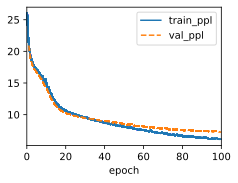

In [46]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
rnn = RNNScratch(num_inputs=len(data.vocab), num_hiddens=32)
model = RNNLMScratch(rnn, vocab_size=len(data.vocab), lr=1)
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

## Decoding

Once a language model has been learned,
we can use it not only to predict the next token
but to continue predicting each subsequent one,
treating the previously predicted token as though
it were the next in the input. 
Sometimes we will just want to generate text
as though we were starting at the beginning 
of a document. 
However, it is often useful to condition
the language model on a user-supplied prefix.
For example, if we were developing an
autocomplete feature for a search engine
or to assist users in writing emails,
we would want to feed in what they 
had written so far (the prefix), 
and then generate a likely continuation.


[**The following `predict` method
generates a continuation, one character at a time,
after ingesting a user-provided `prefix`**].
When looping through the characters in `prefix`,
we keep passing the hidden state
to the next time step 
but do not generate any output.
This is called the *warm-up* period.
After ingesting the prefix, we are now
ready to begin emitting the subsequent characters,
each of which will be fed back into the model 
as the input at the next time step.


## 解码

一旦学习好语言模型后，我们不仅可以利用它来预测下一个词元，还能继续预测后续的每个词元，将先前预测的词元视为输入中的下一个词元。有时我们可能希望像从文档开头那样生成文本。然而，基于用户提供的前缀来调节语言模型通常很有用。例如，如果我们正在开发搜索引擎的自动补全功能或帮助用户撰写电子邮件，我们会希望输入他们已写的内容（前缀），然后生成可能的后续内容。

[**下面的`predict`方法在接收用户提供的`prefix`后，逐个字符生成后续内容**]。在遍历`prefix`中的字符时，我们会将隐藏状态传递给下一个时间步，但不生成任何输出。这称为*预热*期。接收完前缀后，我们开始生成后续字符，每个字符都会作为下一个时间步的输入反馈给模型。

In [51]:
@d2l.add_to_class(RNNLMScratch)  #@save
def predict(self, prefix, num_preds, vocab, device=None):
    state, outputs = None, [vocab[prefix[0]]]
    for i in range(len(prefix) + num_preds - 1):
        X = torch.tensor([[outputs[-1]]], device=device)
        embs = self.one_hot(X)
        rnn_outputs, state = self.rnn(embs, state)
        if i < len(prefix) - 1:  # Warm-up period
            outputs.append(vocab[prefix[i + 1]])
        else:  # Predict num_preds steps
            Y = self.output_layer(rnn_outputs)
            outputs.append(int(Y.argmax(axis=2).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

In the following, we specify the prefix 
and have it generate 20 additional characters.


在下面代码中，我们指定前缀并让它生成20个额外字符。

In [52]:
model.predict('it has', 20, data.vocab, d2l.try_gpu())

'it has of the the the the '

While implementing the above RNN model from scratch is instructive, it is not convenient.
In the next section, we will see how to leverage deep learning frameworks to whip up RNNs
using standard architectures, and to reap performance gains 
by relying on highly optimized library functions.


## Summary

We can train RNN-based language models to generate text following the user-provided text prefix. 
A simple RNN language model consists of input encoding, RNN modeling, and output generation.
During training, gradient clipping can mitigate the problem of exploding gradients but does not address the problem of vanishing gradients. In the experiment, we implemented a simple RNN language model and trained it with gradient clipping on sequences of text, tokenized at the character level. By conditioning on a prefix, we can use a language model to generate likely continuations, which proves useful in many applications, e.g., autocomplete features.


## Exercises

1. Does the implemented language model predict the next token based on all the past tokens up to the very first token in *The Time Machine*? 
1. Which hyperparameter controls the length of history used for prediction?
1. Show that one-hot encoding is equivalent to picking a different embedding for each object.
1. Adjust the hyperparameters (e.g., number of epochs, number of hidden units, number of time steps in a minibatch, and learning rate) to improve the perplexity. How low can you go while sticking with this simple architecture?
1. Replace one-hot encoding with learnable embeddings. Does this lead to better performance?
1. Conduct an experiment to determine how well this language model 
   trained on *The Time Machine* works on other books by H. G. Wells,
   e.g., *The War of the Worlds*.
1. Conduct another experiment to evaluate the perplexity of this model
   on books written by other authors. 
1. Modify the prediction method so as to use sampling 
   rather than picking the most likely next character.
    * What happens?
    * Bias the model towards more likely outputs, e.g., 
    by sampling from $q(x_t \mid x_{t-1}, \ldots, x_1) \propto P(x_t \mid x_{t-1}, \ldots, x_1)^\alpha$ for $\alpha > 1$.
1. Run the code in this section without clipping the gradient. What happens?
1. Replace the activation function used in this section with ReLU 
   and repeat the experiments in this section. Do we still need gradient clipping? Why?


## 总结

我们可以训练基于RNN的语言模型来生成用户提供文本前缀后的后续文本。一个简单的RNN语言模型由输入编码、RNN建模和输出生成组成。在训练过程中，梯度裁剪可以缓解梯度爆炸问题，但不能解决梯度消失问题。在实验中，我们实现了一个简单的RNN语言模型，并在字符级标记化的文本序列上使用梯度裁剪进行训练。通过基于前缀的条件生成，我们可以使用语言模型生成可能的后续内容，这在许多应用中很有用，例如自动补全功能。

## 练习

1. 实现的语言模型是否基于从《时间机器》第一个词元开始的所有历史词元来预测下一个词元？
2. 哪个超参数控制用于预测的历史长度？
3. 证明独热编码等价于为每个对象选择不同的嵌入。
4. 调整超参数（如epoch数、隐藏单元数、minibatch中的时间步数和学习率）以改进困惑度。在使用这个简单架构的情况下，最低能达到多少？
5. 用可学习的嵌入替换独热编码。这会带来更好的性能吗？
6. 进行实验，确定这个在《时间机器》上训练的语言模型在H.G. Wells的其他书籍（如《世界大战》）上的表现如何。
7. 进行另一个实验，评估该模型在其他作者书籍上的困惑度。
8. 修改预测方法，使用采样而不是选择最可能的下一个字符。
   * 会发生什么？
   * 通过从$q(x_t \mid x_{t-1}, \ldots, x_1) \propto P(x_t \mid x_{t-1}, \ldots, x_1)^\alpha$（$\alpha > 1$）采样，使模型偏向更可能的输出。
9. 在不裁剪梯度的情况下运行本节代码。会发生什么？
10. 将本节使用的激活函数替换为ReLU并重复本节实验。我们是否仍然需要梯度裁剪？为什么？

[Discussions](https://discuss.d2l.ai/t/486)
